# Does dual-price's learned bias track the training-year price spread?

Scope: `9_analysis/single_price_gradient_mechanism.md`'s closing "Open thread" proposed
but never computed the cleanest version of this check -- the mean signed day-ahead/
imbalance spread by hour, over the **training period specifically** (not the test period
used for the correlation checks in `bias_spread_solar_mediation.md`), compared against
the trained model's own bias. This notebook builds that, for dual-price: **hourly bias on
the sealed TEST year** (what the deployed model actually does) plotted against **hourly
mean `da - imb` spread on the TRAINING year** (what the model's gradient actually saw
while learning) -- on the same graph, so a shape match (or mismatch) between the two
curves is visible directly, not just as a correlation coefficient.

This is a different cut from `bias_spread_solar_mediation.md` Section 2/5a's pointwise/
day-to-day correlation checks (which found the relationship period-fragile and, net of the
shared solar-driven component, explaining <1.3% of the residual divergence) -- here both
series are collapsed to a single hour-of-day curve first, and the TRAIN/TEST split is
deliberate (learned-from vs deployed-on), rather than checking train and test against each
other's own same-period spread. If dual-price genuinely learned "spread-weighted
accuracy" from the training year, the shapes should visibly track; if the dominant driver
is the shared solar/duck-curve effect established elsewhere in this folder, they need not.

Bias is DFL dual-price's own signed bias (`mean - realised`, N=5 seed-averaged, same
convention as `forecast_characteristics.ipynb` Section 10d) on the test year. Spread is
`da - imb` (true settlement prices), averaged by hour over every training-year day --
deterministic, no model/seed dependence at all.

In [1]:
from __future__ import annotations
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
sys.path.insert(0, str(here() / "7_model_training"))
from eval_raw import (
    load_test_windows, forecast_quantiles, fresh_baseline_model, dfl_model_from,
    FORECASTING_DIR, DFL_TRAIN_DIR, COPULA_DIR,
)
from dfl_train_utils import (
    TRAIN_START, VAL_START, HIST_COLS, FEAT_COLS, EXO_COLS, PRICE_COLS_ALL,
    ISSUE_HOUR, HORIZON, N_HIST, DATA_DIR, reindex_and_impute, build_features, make_windows,
)
from copula_lib import FrozenCopulaSampler
import pickle

SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]
DEFAULT_SEED = 20240801


def seed_variant(base_id, seed):
    return base_id if seed == DEFAULT_SEED else f"{base_id}_seed{seed}"


print("loading test windows (for bias) and training windows (for spread)...")
test_windows = load_test_windows()

base_raw = reindex_and_impute(pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"]).set_index("datetime"),
                               HIST_COLS, freq="1h", warn_gap=6)
frame = build_features(base_raw, feature_cols=FEAT_COLS, price_cols=PRICE_COLS_ALL)
win_kw = dict(gate_aligned_only=True, issue_hour=ISSUE_HOUR, hist_cols=HIST_COLS, exo_cols=EXO_COLS,
              target_col="prosumption", price_cols=PRICE_COLS_ALL, n_hist=N_HIST, horizon=HORIZON)
train_windows = make_windows(frame, y_range=(TRAIN_START, VAL_START - pd.Timedelta(hours=1)), **win_kw)

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = baseline_ckpt["scaler_stats"]

cop = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
sampler = FrozenCopulaSampler(cop["Z_corr"], cop["quantile_levels"])


def load_dfl(forecaster_id):
    ck = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    return dfl_model_from(baseline_ckpt, ck)


print(f"n_train_days={len(train_windows.delivery_start)}  n_test_days={len(test_windows.delivery_start)}")

loading test windows (for bias) and training windows (for spread)...
[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)


[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
n_train_days=365  n_test_days=366


## Hourly dual-price bias, test year (N=5 seed-averaged)

In [2]:
def hourly_bias_own(model, windows):
    """Mean SIGNED error by hour-of-day (mean - realised), each forecaster's own bias --
    same definition as forecast_characteristics.ipynb Section 10d."""
    errs = []
    for d in range(len(windows.delivery_start)):
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d])
        mean, _ = sampler.mean_and_errors(q)
        mean = mean.detach().cpu().numpy()
        realised = np.asarray(windows.y[d], float)
        errs.append(mean - realised)
    return np.mean(errs, axis=0)   # (24,)


bias_curves = np.array([hourly_bias_own(load_dfl(seed_variant("dfl_1stage_dual-price", seed)), test_windows)
                          for seed in SEEDS])
bias_mean, bias_std = bias_curves.mean(axis=0), bias_curves.std(axis=0)
print("dual-price test-year bias (mean across seeds):", np.round(bias_mean, 4))

dual-price test-year bias (mean across seeds): [0.0411 0.1025 0.1086 0.1143 0.1295 0.163  0.2596 0.2594 0.1877 0.1322
 0.1649 0.0633 0.0564 0.0983 0.1665 0.1688 0.0838 0.1193 0.1398 0.1846
 0.1963 0.1484 0.0951 0.1369]


## Hourly day-ahead minus imbalance spread, training year (deterministic, no model)

In [3]:
def hourly_spread(windows):
    """Mean (da - imb), true settlement prices, by hour, averaged over every day in
    `windows`. windows.price columns are PRICE_COLS_ALL order: [da, imb, imb_up,
    imb_down, da_fc, imb_fc, imb_up_fc, imb_down_fc] -- da is column 0, imb is column 1."""
    spreads = []
    for d in range(len(windows.delivery_start)):
        price_day = np.asarray(windows.price[d], float)
        spreads.append(price_day[:, 0] - price_day[:, 1])   # da - imb
    return np.mean(spreads, axis=0)   # (24,)


train_spread = hourly_spread(train_windows)
print("training-year mean (da - imb) spread by hour:", np.round(train_spread, 2))

training-year mean (da - imb) spread by hour: [-0.76 -2.75 -2.74 -3.01 -1.02 -0.57  1.39  2.07  1.38  1.   -1.53 -2.63
 -3.43 -3.26 -1.01 -1.2   2.98  4.95  7.11  3.3   2.22 -0.05 -1.81  1.24]


## Plot -- both series on the same graph (twin y-axes)

Left axis: dual-price's own test-year bias (MW, N=5 seed mean +/- std band). Right axis:
training-year mean `da - imb` spread (GBP/MWh). Same x-axis (hour), different units and
scales -- a twin axis lets the SHAPES be compared visually without forcing a common
scale, which would be misleading here (bias and spread aren't the same quantity and
there's no natural unit conversion between them).

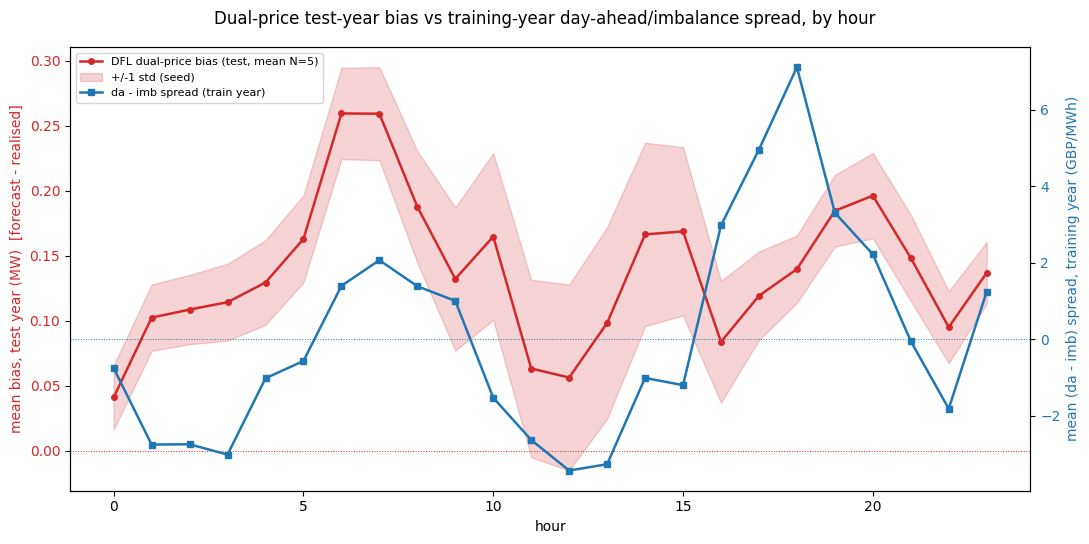

In [4]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))
h = np.arange(24)

color_bias = "C3"
ax1.plot(h, bias_mean, "-o", color=color_bias, markersize=4, linewidth=1.8, label="DFL dual-price bias (test, mean N=5)")
ax1.fill_between(h, bias_mean - bias_std, bias_mean + bias_std, color=color_bias, alpha=0.2, label="+/-1 std (seed)")
ax1.axhline(0, color=color_bias, linewidth=0.7, linestyle=":")
ax1.set_xlabel("hour")
ax1.set_ylabel("mean bias, test year (MW)  [forecast - realised]", color=color_bias)
ax1.tick_params(axis="y", labelcolor=color_bias)

ax2 = ax1.twinx()
color_spread = "C0"
ax2.plot(h, train_spread, "-s", color=color_spread, markersize=4, linewidth=1.8, label="da - imb spread (train year)")
ax2.axhline(0, color=color_spread, linewidth=0.7, linestyle=":")
ax2.set_ylabel("mean (da - imb) spread, training year (GBP/MWh)", color=color_spread)
ax2.tick_params(axis="y", labelcolor=color_spread)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

fig.suptitle("Dual-price test-year bias vs training-year day-ahead/imbalance spread, by hour", fontsize=12)
fig.tight_layout()
plt.show()

## Correlation check (quantifies what the plot shows visually)

A shape match in the plot above is suggestive but not precise -- R^2 between the two
hour-of-day curves puts a number on it. Contrast against `bias_spread_solar_mediation.md`
Section 2's pointwise/same-period finding (test-year delta_dual vs spread_up: R^2=0.437;
train-year: R^2=0.013) -- this is a different comparison (train-year spread vs
TEST-year bias, hour-of-day collapsed, dual-price's own bias not a delta-vs-baseline),
so a different number here is expected, not a contradiction.

In [5]:
from scipy import stats

r, p = stats.pearsonr(train_spread, bias_mean)
print(f"corr(train-year da-imb spread, test-year dual-price bias), hour-of-day: r={r:.4f}  R^2={r**2:.4f}  p={p:.4f}")

corr(train-year da-imb spread, test-year dual-price bias), hour-of-day: r=0.4009  R^2=0.1608  p=0.0522
